In [1]:
# import libraries
import numpy as np 
import pandas as pd 

In [2]:
pip install tensorflow 

Note: you may need to restart the kernel to use updated packages.


In [5]:
# import/load dataset
train_df= pd.read_csv('sign_mnist_train.csv')
test_df= pd.read_csv('sign_mnist_test.csv')

In [6]:
train_df[:2]

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149


In [7]:
# check shape of dataset
train_df.shape, test_df.shape

((27455, 785), (7172, 785))

In [8]:
# split datset into x and y splits
x_train= train_df.drop('label', axis=1)
y_train= train_df['label']

In [9]:
x_test= test_df.drop('label', axis=1)
y_test= test_df['label']

In [10]:
x_train.shape, x_test.shape

((27455, 784), (7172, 784))

In [11]:
# check min and max values from training data
x_train.min() , x_train.max()

(pixel1      0
 pixel2      0
 pixel3      0
 pixel4      0
 pixel5      0
            ..
 pixel780    0
 pixel781    0
 pixel782    0
 pixel783    0
 pixel784    0
 Length: 784, dtype: int64,
 pixel1      255
 pixel2      255
 pixel3      255
 pixel4      255
 pixel5      255
            ... 
 pixel780    255
 pixel781    255
 pixel782    255
 pixel783    255
 pixel784    255
 Length: 784, dtype: int64)

In [12]:
# check datatype 
x_train.dtypes

pixel1      int64
pixel2      int64
pixel3      int64
pixel4      int64
pixel5      int64
            ...  
pixel780    int64
pixel781    int64
pixel782    int64
pixel783    int64
pixel784    int64
Length: 784, dtype: object

In [13]:
# pixel value first training image
x_train.iloc[0]

#iloc: interger location based indexing, it shows first image by indexing or pixel values.

pixel1      107
pixel2      118
pixel3      127
pixel4      134
pixel5      139
           ... 
pixel780    206
pixel781    206
pixel782    204
pixel783    203
pixel784    202
Name: 0, Length: 784, dtype: int64

In [14]:
# Normalizing the pixel values of images
x_train= x_train/255.0
x_test= x_test/255.0

In [15]:
x_train.min(), x_train.max()

(pixel1      0.0
 pixel2      0.0
 pixel3      0.0
 pixel4      0.0
 pixel5      0.0
            ... 
 pixel780    0.0
 pixel781    0.0
 pixel782    0.0
 pixel783    0.0
 pixel784    0.0
 Length: 784, dtype: float64,
 pixel1      1.0
 pixel2      1.0
 pixel3      1.0
 pixel4      1.0
 pixel5      1.0
            ... 
 pixel780    1.0
 pixel781    1.0
 pixel782    1.0
 pixel783    1.0
 pixel784    1.0
 Length: 784, dtype: float64)

In [16]:
# show min, max, and total classes of data/ images
print("Min:", y_train.min())
print("max:", y_train.max())
print('classes:', len(np.unique(y_train)))

Min: 0
max: 24
classes: 24


In [1]:
#because there is no J that why label 9 is skipped so labels are as 0,1,2,3,4,5,6,7,8,10,11......24 

In [17]:
# encoding 
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

#label encoding make the labels continuous and clean.
#labels are now as 1,2,3,4,5,6,7,8,9,10,....23.

In [18]:
y_train= le.fit_transform(y_train)
y_test= le.transform(y_test)

In [19]:
print("Min:", y_train.min())
print("max:", y_train.max())
print('classes:', len(np.unique(y_train)))

Min: 0
max: 23
classes: 24


In [20]:
# one-hot encoding
from tensorflow.keras.utils import to_categorical

In [21]:
y_train= to_categorical(y_train, 24)
y_test= to_categorical(y_test, 24)

#convert labels to categorical vectors.

In [22]:
x_train.shape, y_train.shape

((27455, 784), (27455, 24))

In [23]:
# import models and layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ( Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization)

#sequential: linear model.simple and no branching
#Conv2D: convolutional layer,apply fiters that slides over the image.learn features 
#maxpooling:reduce size of feature map, reduce computation, prevent overfitting.
#batchNormalization: normalizes the output.
#dropout: randomly disable neurons.

In [24]:
# resape the train test values 
x_train= x_train.values.reshape(-1, 28, 28, 1)
x_test= x_test.values.reshape(-1, 28, 28, 1)

#data present is in 1D vector but CNN expect images of 2D.
#shape is (27455, 784) reshape into -1, 28, 28, 1
# means -1 = 27455, 28x28= heightx width= 784, 1 means number of channel.
# MNIST images are grayscale so 1.

In [25]:
model= Sequential([
    Conv2D(32, (3,3), activation= 'relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3,3), activation= 'relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3,3), activation= 'relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(256, activation= 'relu'),
    Dropout(0.5),
    Dense(24, activation='softmax')
])

#32 different kernals of 3x3 pixel shape, each kernal learn different features
#batchnormalization:

C:\Users\Pawanpreet Kaur\anaconda3\envs\Tensor_Flow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(optimizer= 'adam',
             loss= 'categorical_crossentropy',
             metrics= ['accuracy'])

In [27]:
x_train.shape, y_train.shape

((27455, 28, 28, 1), (27455, 24))

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,760 (518.59 KB)

 Trainable params: 132,312 (516.84 KB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
model.fit(x_train, y_train, validation_split= 0.2)

687/687 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.8518 - loss: 0.5009 - val_accuracy: 0.9669 - val_loss: 0.1577


In [30]:
history= model.fit(x_train, y_train, validation_split= 0.2,
                  epochs=20,
                  batch_size= 64,
                  verbose=1)

Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - accuracy: 0.9976 - loss: 0.0123 - val_accuracy: 0.9913 - val_loss: 0.0241
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.9995 - loss: 0.0040 - val_accuracy: 0.9998 - val_loss: 7.5235e-04
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.9995 - loss: 0.0035 - val_accuracy: 0.9996 - val_loss: 0.0025
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.9996 - loss: 0.0025 - val_accuracy: 0.9996 - val_loss: 0.0028
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.9952 - loss: 0.0169 - val_accuracy: 0.9842 - val_loss: 0.0531
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.9952 - loss: 0.0160 - val_accuracy: 0.9925 - val_loss: 0.0310
Epoch 7/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - accuracy: 0.9983 - loss: 0.0059 - val_accuracy: 0.9333 - val_loss: 0.2082
Epoch 8/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.9903 - loss: 0.032

In [31]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [32]:
history.history['val_loss']

[0.024069929495453835,
 0.0007523538661189377,
 0.002533701015636325,
 0.0028186289127916098,
 0.05313153192400932,
 0.03098691627383232,
 0.2081598937511444,
 0.5278216600418091,
 0.05452149733901024,
 0.04979091137647629,
 0.0006029611104167998,
 4.864870788878761e-06,
 5.73486568100634e-06,
 0.4286360740661621,
 0.7519675493240356,
 0.01865473762154579,
 0.045232415199279785,
 0.09561260044574738,
 0.09614044427871704,
 0.0018986024660989642]

In [33]:
test_loss, test_accuracy= model.evaluate(x_test, y_test)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9176 - loss: 0.4594


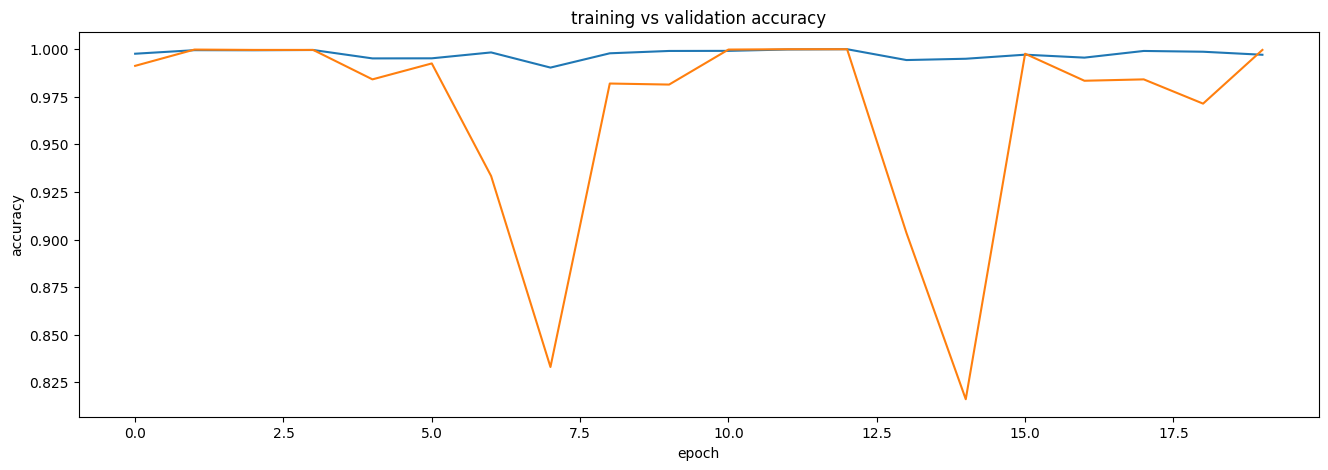

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 5))
plt.plot(history.history['accuracy'], label= 'Training accuracy')
plt.plot(history.history['val_accuracy'], label= 'validstion accuracy')
plt.title('training vs validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [35]:
y_pred= model.predict(x_test)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


In [36]:
y_pred[:1]

array([[1.0681366e-12, 8.6808721e-10, 6.5566226e-08, 2.2263887e-11,
        5.0478022e-09, 3.7687663e-02, 9.6230888e-01, 1.8706751e-10,
        8.3181580e-11, 4.2948359e-10, 1.5753785e-09, 3.8217164e-12,
        1.7733145e-09, 1.6492792e-06, 4.9379572e-09, 3.6827857e-10,
        5.2536742e-12, 1.2489484e-10, 2.6791666e-08, 8.5129001e-11,
        5.6670476e-12, 1.6752042e-09, 1.6818467e-06, 7.4186005e-11]],
      dtype=float32)

In [37]:
y_pred_classes= y_pred.argmax(axis=1)

In [38]:
y_pred_classes[:1]

array([6])

In [39]:
y_test[:1]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.]])

In [40]:
y_true= np.argmax(y_test, axis=1)

In [41]:
y_pred= model.predict(x_test)
y_pred= np.argmax(y_pred, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [42]:
from sklearn.metrics import classification_report, confusion_matrix

In [43]:
classification_report(y_true, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.99      1.00      0.99       331\n           1       1.00      0.99      0.99       432\n           2       0.84      1.00      0.91       310\n           3       0.93      0.92      0.93       245\n           4       1.00      0.95      0.97       498\n           5       0.98      1.00      0.99       247\n           6       0.93      0.82      0.87       348\n           7       0.88      0.95      0.92       436\n           8       0.93      0.91      0.92       288\n           9       1.00      0.93      0.97       331\n          10       0.99      0.94      0.97       209\n          11       1.00      0.91      0.95       394\n          12       0.75      0.92      0.83       291\n          13       1.00      0.81      0.90       246\n          14       0.99      1.00      0.99       347\n          15       1.00      1.00      1.00       164\n          16       0.74      0.43      0.54       144\n       

In [44]:
confusion_matrix(y_true, y_pred)

array([[331,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 426,   0,   0,   0,   4,   0,   0,   0,   0,   1,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0],
       [  0,   0, 310,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 226,   0,   0,   0,   0,   0,   0,   0,   0,  19,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0, 471,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  27,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 247,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 286,  57,   0,   0,   0,   0,   0,
          0,   5,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  20

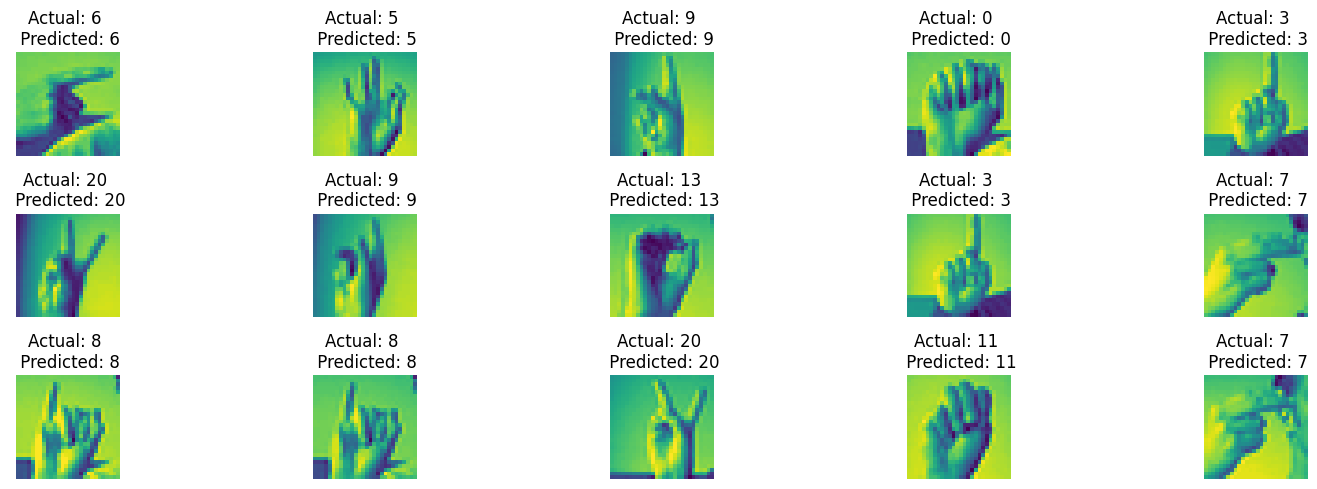

In [45]:
plt.figure(figsize=(16,5))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title(f'Actual: {y_true[i]} \n Predicted: {y_pred_classes[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [46]:
model.save('sign_lang.keras')